In [2]:
import pandas as pd
df=pd.read_csv(r'C:/Users/rajes/OneDrive/Desktop/projects/customer_segmentation/data.csv',encoding='cp1252')

In [3]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
df['Date']=pd.to_datetime(df['InvoiceDate'])

In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Date
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,2010-12-01 08:26:00
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,2010-12-01 08:26:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,2010-12-01 08:26:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,2010-12-01 08:26:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,2010-12-01 08:26:00


In [6]:
#to calculate the recency
df['Rank']=df.sort_values(['CustomerID','Date']).groupby(['CustomerID'])['Date'].rank(method='min').astype('Int64')
df_rec=df[df['Rank']==1]

In [7]:
df_rec['Recency']=(df_rec['Date']-pd.to_datetime(min(df_rec['Date']))).dt.days

C:\Users\rajes\AppData\Local\Temp\ipykernel_51944\3200930936.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rec['Recency']=(df_rec['Date']-pd.to_datetime(min(df_rec['Date']))).dt.days


In [8]:
df_rec.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Date,Rank,Recency
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,2010-12-01 08:26:00,1,0
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,1,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,2010-12-01 08:26:00,1,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,1,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,2010-12-01 08:26:00,1,0
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom,2010-12-01 08:26:00,1,0
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom,2010-12-01 08:26:00,1,0
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom,2010-12-01 08:34:00,1,0
10,536367,22745,POPPY'S PLAYHOUSE BEDROOM,6,12/1/2010 8:34,2.10,13047.0,United Kingdom,2010-12-01 08:34:00,1,0
11,536367,22748,POPPY'S PLAYHOUSE KITCHEN,6,12/1/2010 8:34,2.10,13047.0,United Kingdom,2010-12-01 08:34:00,1,0


In [9]:
# to calculate the frequency
freq=df_rec.groupby('CustomerID')['Date'].count()
df_freq=pd.DataFrame(freq).reset_index()
df_freq.columns=['CustomerID','Frequency']
df_freq.head()

,CustomerID,Frequency
0,12346.0,1
1,12347.0,31
2,12348.0,17
3,12349.0,73
4,12350.0,17


In [10]:
rec_freq=df_freq.merge(df_rec,on='CustomerID')

In [11]:
rec_freq.head()

,CustomerID,Frequency,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Country,Date,Rank,Recency
0,12346.0,1,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1/18/2011 10:01,1.04,United Kingdom,2011-01-18 10:01:00,1,48
1,12347.0,31,537626,85116,BLACK CANDELABRA T-LIGHT HOLDER,12,12/7/2010 14:57,2.10,Iceland,2010-12-07 14:57:00,1,6
2,12347.0,31,537626,22375,AIRLINE BAG VINTAGE JET SET BROWN,4,12/7/2010 14:57,4.25,Iceland,2010-12-07 14:57:00,1,6
3,12347.0,31,537626,71477,COLOUR GLASS. STAR T-LIGHT HOLDER,12,12/7/2010 14:57,3.25,Iceland,2010-12-07 14:57:00,1,6
4,12347.0,31,537626,22492,MINI PAINT SET VINTAGE,36,12/7/2010 14:57,0.65,Iceland,2010-12-07 14:57:00,1,6


In [12]:
print(rec_freq.columns)

Index(['CustomerID', 'Frequency', 'InvoiceNo', 'StockCode', 'Description',
       'Quantity', 'InvoiceDate', 'UnitPrice', 'Country', 'Date', 'Rank',
       'Recency'],
      dtype='object')


In [13]:
rec_freq['total']=rec_freq['Quantity']*df['UnitPrice']

In [14]:
mon=rec_freq.groupby('CustomerID')['total'].sum()
mon=pd.DataFrame(mon).reset_index()
mon.columns=['CustomerID','Monetory_value']
mon.head()

,CustomerID,Monetory_value
0,12346.0,189248.25
1,12347.0,1246.73
2,12348.0,4311.90
3,12349.0,1618.81
4,12350.0,553.25


In [15]:
rec_freq_mon=mon.merge(rec_freq,on='CustomerID')
rec_freq_mon.head()

,CustomerID,Monetory_value,Frequency,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Country,Date,Rank,Recency,total
0,12346.0,189248.25,1,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1/18/2011 10:01,1.04,United Kingdom,2011-01-18 10:01:00,1,48,189248.25
1,12347.0,1246.73,31,537626,85116,BLACK CANDELABRA T-LIGHT HOLDER,12,12/7/2010 14:57,2.10,Iceland,2010-12-07 14:57:00,1,6,40.68
2,12347.0,1246.73,31,537626,22375,AIRLINE BAG VINTAGE JET SET BROWN,4,12/7/2010 14:57,4.25,Iceland,2010-12-07 14:57:00,1,6,11.00
3,12347.0,1246.73,31,537626,71477,COLOUR GLASS. STAR T-LIGHT HOLDER,12,12/7/2010 14:57,3.25,Iceland,2010-12-07 14:57:00,1,6,40.68
4,12347.0,1246.73,31,537626,22492,MINI PAINT SET VINTAGE,36,12/7/2010 14:57,0.65,Iceland,2010-12-07 14:57:00,1,6,122.04


In [16]:
final_df=rec_freq_mon[['CustomerID','Recency','Frequency','Monetory_value']]

Recency:


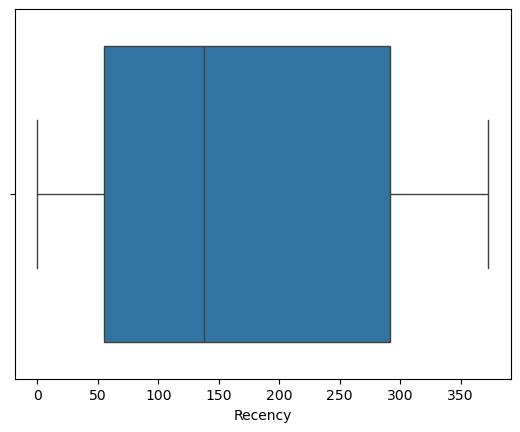

Frequency:


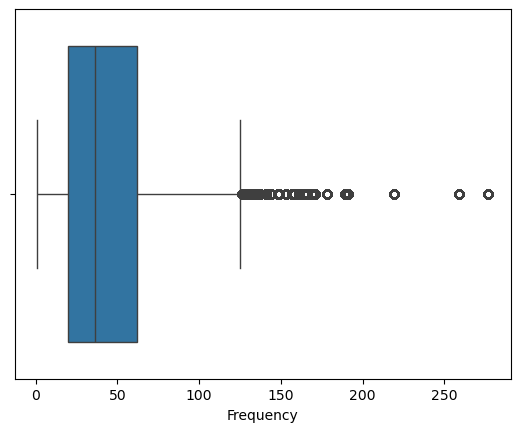

Monetory_value:


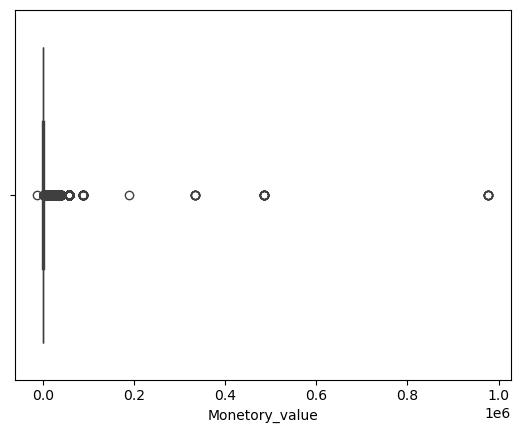

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
list1=['Recency','Frequency','Monetory_value']
for i in list1:
    print(str(i)+':')
    ax=sns.boxplot(x=final_df[str(i)])
    plt.show(ax)

In [18]:
from scipy import stats
import numpy as np
new_df=final_df[['Recency','Frequency','Monetory_value']]
z_scores=stats.zscore(new_df)
abs_z_scores=np.abs(z_scores)
filtered_enteries=(abs_z_scores<3).all(axis=1)
new_df=new_df[filtered_enteries]
new_df.head()

,Recency,Frequency,Monetory_value
1,6,31,1246.73
2,6,31,1246.73
3,6,31,1246.73
4,6,31,1246.73
5,6,31,1246.73


In [19]:
from sklearn.preprocessing import StandardScaler
new_df=new_df.drop_duplicates()
new_df.head()

,Recency,Frequency,Monetory_value
1,6,31,1246.73
32,15,17,4311.90
49,355,73,1618.81
122,63,17,553.25
139,77,15,947.61


In [69]:
col_names=['Recency','Frequency','Monetory_value']
features=new_df[col_names]
scaler=StandardScaler().fit(features.values)
features=scaler.transform(features.values)
scaled_features=pd.DataFrame(features,columns=col_names)
scaled_features.head()

,Recency,Frequency,Monetory_value
0,-1.196723,0.379971,0.185080
1,-1.120665,-0.259085,1.965919
2,1.752654,2.297138,0.401256
3,-0.715020,-0.259085,-0.217826
4,-0.596706,-0.350378,0.011294


In [45]:
from sklearn.cluster import KMeans

SSE=[]
k_range=range(1,11)
for i in k_range:
    k=KMeans(n_clusters=i,init='k-means++')
    k.fit(scaled_features)
    SSE.append(k.inertia_)
    #labels=k.labels_
    #final_centroids=k.cluster_centers_

SSE
#print(labels)
#print(final_centroids)

[4353.0,
 927.5057238054114,
 384.3319960918853,
 201.48143769664443,
 136.08616118693803,
 93.76381331299694,
 61.92069631689655,
 45.14670789578776,
 35.167574829970256,
 28.040360561686356]

Text(0, 0.5, 'SSE')

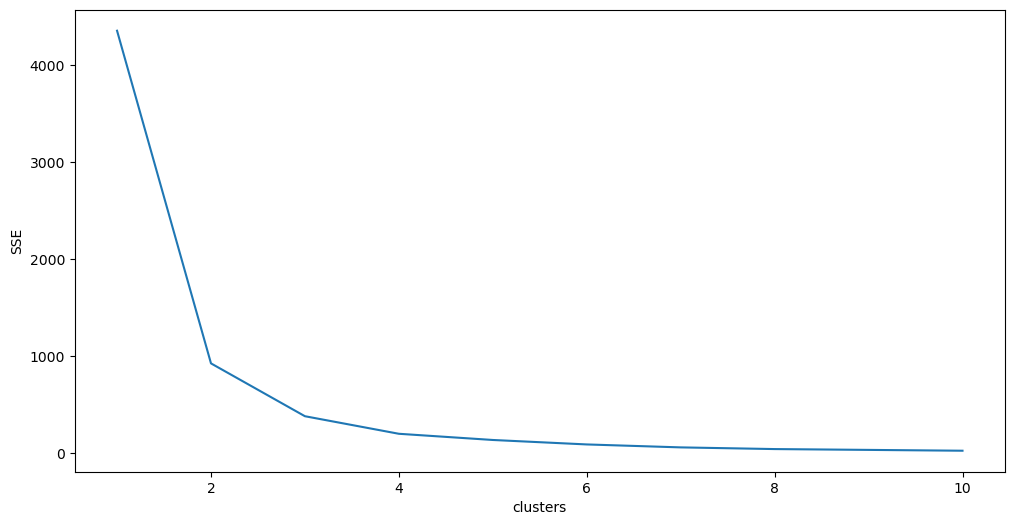

In [40]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(k_range,SSE)
plt.xlabel('clusters')
plt.ylabel('SSE')

In [49]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

for i in range(3,5):
    k=KMeans(n_clusters=i,init='k-means++')
    labels=k.fit_predict(scaled_features)
    print(i,silhouette_score(scaled_features,labels,metric='euclidean'))
    



3 0.6298775170342676
4 0.6293455379222684


In [53]:

pred=k.predict(scaled_features)
frame=pd.DataFrame(new_df)
frame['cluster']=pred
frame

,Recency,Frequency,Monetory_value,cluster
1,6,31,1246.73,2
32,15,17,4311.90,2
49,355,73,1618.81,0
122,63,17,553.25,1
139,77,15,947.61,1
...,...,...,...,...
100700,96,10,229.79,1
100710,193,7,92.29,3
100717,247,7,159.91,3
100724,36,57,201.54,2


In [62]:
avg_df=frame.groupby('cluster').mean().reset_index()
print(avg_df)

   cluster     Recency  Frequency  Monetory_value
0        0  317.212011  27.606005     1111.451956
1        1  101.413823  21.869641      852.889230
2        2   18.798653  19.948353      832.828069
3        3  197.280000  21.575484      943.653277


C:\Users\rajes\AppData\Local\Temp\ipykernel_51944\3425351517.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x='cluster',y=str(i),data=avg_df,palette=palette)


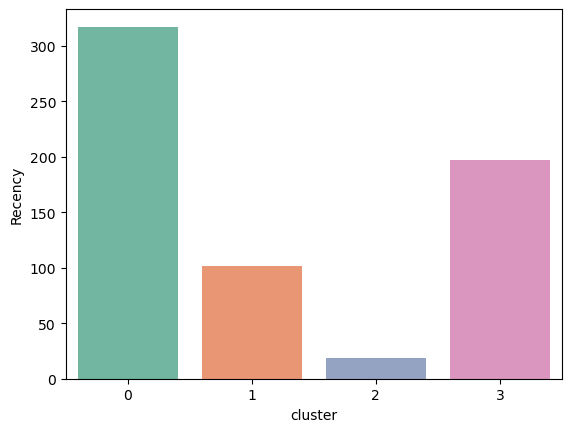

C:\Users\rajes\AppData\Local\Temp\ipykernel_51944\3425351517.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x='cluster',y=str(i),data=avg_df,palette=palette)


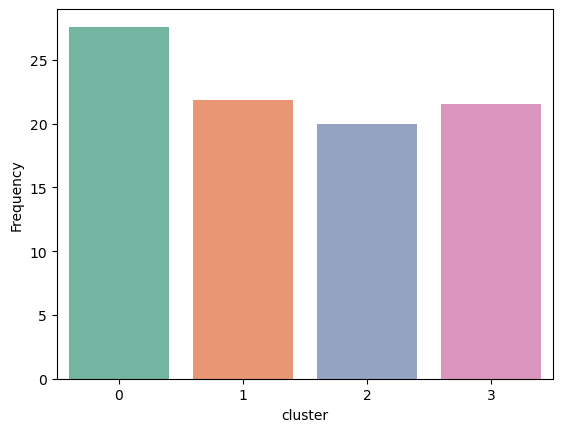

C:\Users\rajes\AppData\Local\Temp\ipykernel_51944\3425351517.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.barplot(x='cluster',y=str(i),data=avg_df,palette=palette)


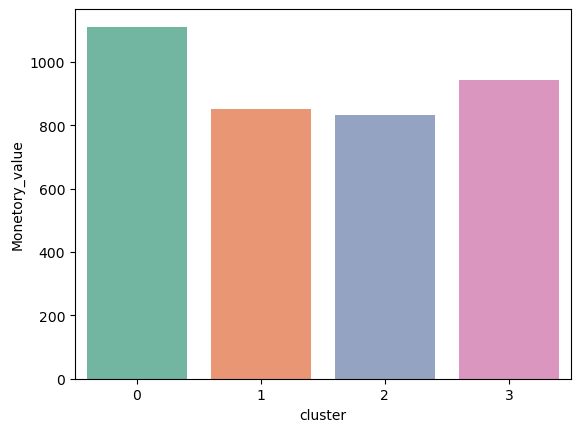

In [70]:
palette = sns.color_palette("Set2", n_colors=avg_df['cluster'].nunique())


for i in list1:
    ax=sns.barplot(x='cluster',y=str(i),data=avg_df,palette=palette)
    legend = ax.get_legend()
    if legend:
        legend.remove()

    plt.show()